# Clustering

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm


import seaborn as sns
import math
import random
from itertools import combinations

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import pairwise_distances_argmin_min
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import BallTree
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

import cartopy.crs as ccrs
import cartopy.feature as cfeature


## Introduction

The clustering is effectuated on all 1° grid points from continental shelf. Some of the data points have associated observed fiber and/or fragment concentration, $Q_{grid}$. Even though the acceptance conditions are defined based on fiber concentrations, both fiber and fragment concentrations are joined to the world dataframe.

### Fibers and fragments together

In [2]:
df_frg = pd.read_csv('..\\0.4 Feature selection\\Fragments parameters for clustering.csv')
df_fib = pd.read_csv('..\\0.4 Feature selection\\Fibers parameters for clustering.csv')

In [3]:
df_merged = df_fib.merge(df_frg[['Lat_center', 'Lon_center', 'MEAN MP stock (g/m2) in 2021']], 
                          on=['Lat_center', 'Lon_center'], 
                          how='outer',  # keep all points from both
                          suffixes=('_fib', '_frg'))

# Fill NaN with 0 before summing
df_merged['MEAN MP stock (g/m2) in 2021_fib'] = df_merged['MEAN MP stock (g/m2) in 2021_fib']
df_merged['MEAN MP stock (g/m2) in 2021_frg'] = df_merged['MEAN MP stock (g/m2) in 2021_frg']

#df_merged['Conc sum fibres fragments'] = df_merged['MEAN MP stock (g/m2) in 2021_fib'] + df_merged['MEAN MP stock (g/m2) in 2021_frg']

In [4]:
df_merged = df_merged.drop(index = 7, axis = 0)  # Drop Rio the outlier
df_merged = df_merged.reset_index()
df_merged['index'] = np.arange(0,len(df_merged), 1)
df_merged = df_merged.drop(columns=[	'MP_std',	'n_points',	'Distance Fishing nearest_point',
                                    'Mean Precipitations over 1991-2021',	'MMPW/Area 100km',	'POC',	'PO4',
                                    'PLAS_F',	'Sedimentation rate cm/yr',	'River Input 100km',
                                    'pwg_per_cap nearest_point / dist',])
#df_merged = df_merged.rename(columns={'Conc sum fibres fragments': 'MEAN MP stock (g/m2) in 2021'})

In [5]:
df_merged

,index,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021_fib,MEAN MP stock (g/m2) in 2021_frg
0,0,Fibers,-74.5,163.5,3.353587e-08,0.000001
1,1,Fibers,-74.5,164.5,4.351279e-07,0.000053
2,2,Fibers,-42.5,147.5,1.041953e-02,6.015802
3,3,Fibers,-38.5,144.5,1.395096e-02,14.021070
4,4,Fibers,-35.5,138.5,9.684738e-03,16.066155
...,...,...,...,...,...,...
80,80,NaN,73.5,-169.5,NaN,0.296218
81,81,NaN,73.5,-168.5,NaN,0.315513
82,82,NaN,74.5,-173.5,NaN,0.164797
83,83,NaN,75.5,-179.5,NaN,0.840276


### Plot fiber and fragments concentrations

In [6]:
import warnings
warnings.filterwarnings("ignore") # Suppress all warnings

In [7]:
vmin = min(df_merged['MEAN MP stock (g/m2) in 2021_fib'])
vmax = max(df_merged['MEAN MP stock (g/m2) in 2021_frg'])
norm = LogNorm(vmin=vmin, vmax=vmax)

fig = plt.figure(figsize=(14, 7))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='aliceblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_global()

for row in range(len(df_merged)):

    subset = df_merged.iloc[row]

    if subset['index'] == 18 or subset['index'] == 12 :
        form = '^'
        size = 100
    else :
        form = '.'
        size = 50


    scatter = ax.scatter(subset['Lon_center'],subset['Lat_center'],
                    c=subset['MEAN MP stock (g/m2) in 2021_frg'], 
                    s=size,
                    marker = '.',
                    cmap='jet',  # You can change this to 'plasma', 'hot', 'cool', etc.
                    norm=norm,  # Log scale for better visualization of wide range
                    zorder=5,
                    transform=ccrs.PlateCarree())
    scatter = ax.scatter(subset['Lon_center'],subset['Lat_center'],
                    c=subset['MEAN MP stock (g/m2) in 2021_fib'], 
                    s=size,
                    marker = '^',
                    cmap='jet',  # You can change this to 'plasma', 'hot', 'cool', etc.
                    norm=norm,  # Log scale for better visualization of wide range
                    zorder=5,
                    transform=ccrs.PlateCarree())
    
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', 
                   pad=0.1, shrink=0.8, aspect=40)
cbar.set_label('Observed MP concentrations $Q_{grid} (g/m^2)$', fontsize=12, fontweight='bold')

legend_elements = [
    Line2D([0], [0], marker='.', color='gray', linestyle='None', markersize=8, label='Fragments'),
    Line2D([0], [0], marker='^', color='gray', linestyle='None', markersize=8, label='Fibers')
]
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

: 

## World dataframe

In [7]:
df_all_world = pd.read_csv('Coastal shelf grid with features.csv')
df_all_world['index'] = np.arange(0,len(df_all_world), 1)
df_all_world

,Lat_center,Lon_center,Depth,MP_std,n_points,uo_mean,Distance to land,Distance Fishing nearest_point,Mean Precipitations over 1991-2021,MMPW/Area 100km,...,River Input 50km,River Input 100km,POC,PLAS_F,O2,PO4,Sedimentation rate cm/yr,pwg_per_cap nearest_point / dist,Population_2020 500km / dist,index
0,-81.5,160.5,-44.000000,16.522712,3,NaN,0.0,448.116864,0.401515,0.000000e+00,...,1.668110,1.986781,0.607783,4.406968e-11,325.463806,2.088637,0.126175,0.001361,53320.895916,0
1,-81.5,161.5,-170.000000,4.242641,2,NaN,0.0,443.620441,0.401515,0.000000e+00,...,1.668110,1.986781,0.607783,4.406968e-11,325.463806,2.088637,0.126689,0.001115,53222.282792,1
2,-79.5,160.5,-9.500000,2.121320,2,NaN,0.0,244.808513,0.389836,0.000000e+00,...,1.668110,1.986781,0.607783,4.406968e-11,325.463806,2.088637,0.126783,0.000646,87407.198539,2
3,-79.5,175.5,-178.000000,NaN,1,NaN,31000.0,194.217273,0.482419,0.000000e+00,...,1.668110,1.986781,0.477956,1.410538e-10,325.242401,2.123963,0.126756,0.000696,55215.965181,3
4,-79.5,176.5,-88.000000,121.622366,2,NaN,31000.0,190.495909,0.482419,0.000000e+00,...,1.668110,1.986781,0.477956,1.410538e-10,325.242401,2.123963,0.126780,0.000960,56832.456846,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10163,84.5,-35.5,-187.051282,6.480532,39,-0.002583,0.0,496.790908,0.551590,2.040479e-09,...,1.356485,2.217066,0.054661,1.340686e-03,340.816650,0.869589,NaN,0.002818,432181.629526,10163
10164,84.5,-34.5,-189.600000,5.639149,5,-0.006742,0.0,488.014780,0.551590,2.040479e-09,...,1.356485,2.217066,0.054661,1.340686e-03,340.816650,0.869589,NaN,0.002818,423393.836646,10164
10165,84.5,-32.5,-171.947368,14.001880,19,-0.011208,0.0,471.034100,0.551590,2.040479e-09,...,1.356485,2.217066,0.054661,1.340686e-03,340.816650,0.869589,NaN,0.002319,418336.996098,10165
10166,84.5,-31.5,-156.083333,12.109037,12,-0.012662,0.0,462.855805,0.551590,2.040479e-09,...,1.356485,2.217066,0.054661,1.340686e-03,340.816650,0.869589,NaN,0.003777,394274.240211,10166


In [8]:
df_all_world.keys()

Index(['Lat_center', 'Lon_center', 'Depth', 'MP_std', 'n_points', 'uo_mean',
       'Distance to land', 'Distance Fishing nearest_point',
       'Mean Precipitations over 1991-2021', 'MMPW/Area 100km',
       'Distance Meijer nearest_point', 'River Input 50km',
       'River Input 100km', 'POC', 'PLAS_F', 'O2', 'PO4',
       'Sedimentation rate cm/yr', 'pwg_per_cap nearest_point / dist',
       'Population_2020 500km / dist', 'index'],
      dtype='str')

In [9]:
world_features = ['Depth', 'Distance to land',
       'Distance Fishing nearest_point', 'Mean Precipitations over 1991-2021',
       'MMPW/Area 100km', 'Distance Meijer nearest_point', 'River Input 50km',
       'River Input 100km', 'POC', 'PLAS_F', 'O2', 'PO4',
       'Sedimentation rate cm/yr', 'pwg_per_cap nearest_point / dist',
       'Population_2020 500km / dist',]
len(world_features)

15

### Associate fiber and fragment concentrations with coastal shelf coordinates

In [10]:

# Build BallTree on df_all_world coordinates
coords_world = np.radians(df_all_world[['Lat_center', 'Lon_center']].values)
tree = BallTree(coords_world, metric='haversine')

# Query nearest point in df_all_world for each df_merged point
coords_64 = np.radians(df_merged[['Lat_center', 'Lon_center']].values)
_, indices = tree.query(coords_64, k=1)

# Assign concentration to nearest world point
df_all_world_expanded = df_all_world
df_all_world_expanded['MEAN MP stock (g/m2) in 2021_fib'] = np.nan
df_all_world_expanded.loc[indices.flatten(), 'MEAN MP stock (g/m2) in 2021_fib'] = df_merged['MEAN MP stock (g/m2) in 2021_fib'].values
df_all_world_expanded['MEAN MP stock (g/m2) in 2021_frg'] = np.nan
df_all_world_expanded.loc[indices.flatten(), 'MEAN MP stock (g/m2) in 2021_frg'] = df_merged['MEAN MP stock (g/m2) in 2021_frg'].values

df_all_world_expanded

,Lat_center,Lon_center,Depth,MP_std,n_points,uo_mean,Distance to land,Distance Fishing nearest_point,Mean Precipitations over 1991-2021,MMPW/Area 100km,...,POC,PLAS_F,O2,PO4,Sedimentation rate cm/yr,pwg_per_cap nearest_point / dist,Population_2020 500km / dist,index,MEAN MP stock (g/m2) in 2021_fib,MEAN MP stock (g/m2) in 2021_frg
0,-81.5,160.5,-44.000000,16.522712,3,NaN,0.0,448.116864,0.401515,0.000000e+00,...,0.607783,4.406968e-11,325.463806,2.088637,0.126175,0.001361,53320.895916,0,NaN,NaN
1,-81.5,161.5,-170.000000,4.242641,2,NaN,0.0,443.620441,0.401515,0.000000e+00,...,0.607783,4.406968e-11,325.463806,2.088637,0.126689,0.001115,53222.282792,1,NaN,NaN
2,-79.5,160.5,-9.500000,2.121320,2,NaN,0.0,244.808513,0.389836,0.000000e+00,...,0.607783,4.406968e-11,325.463806,2.088637,0.126783,0.000646,87407.198539,2,NaN,NaN
3,-79.5,175.5,-178.000000,NaN,1,NaN,31000.0,194.217273,0.482419,0.000000e+00,...,0.477956,1.410538e-10,325.242401,2.123963,0.126756,0.000696,55215.965181,3,NaN,NaN
4,-79.5,176.5,-88.000000,121.622366,2,NaN,31000.0,190.495909,0.482419,0.000000e+00,...,0.477956,1.410538e-10,325.242401,2.123963,0.126780,0.000960,56832.456846,4,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10163,84.5,-35.5,-187.051282,6.480532,39,-0.002583,0.0,496.790908,0.551590,2.040479e-09,...,0.054661,1.340686e-03,340.816650,0.869589,NaN,0.002818,432181.629526,10163,NaN,NaN
10164,84.5,-34.5,-189.600000,5.639149,5,-0.006742,0.0,488.014780,0.551590,2.040479e-09,...,0.054661,1.340686e-03,340.816650,0.869589,NaN,0.002818,423393.836646,10164,NaN,NaN
10165,84.5,-32.5,-171.947368,14.001880,19,-0.011208,0.0,471.034100,0.551590,2.040479e-09,...,0.054661,1.340686e-03,340.816650,0.869589,NaN,0.002319,418336.996098,10165,NaN,NaN
10166,84.5,-31.5,-156.083333,12.109037,12,-0.012662,0.0,462.855805,0.551590,2.040479e-09,...,0.054661,1.340686e-03,340.816650,0.869589,NaN,0.003777,394274.240211,10166,NaN,NaN


In [11]:
mask = df_all_world_expanded['MEAN MP stock (g/m2) in 2021_fib'].notna()
df_reduced = df_all_world_expanded[mask]
df_reduced['index'] = np.arange(0,len(df_reduced), 1)
df_reduced

,Lat_center,Lon_center,Depth,MP_std,n_points,uo_mean,Distance to land,Distance Fishing nearest_point,Mean Precipitations over 1991-2021,MMPW/Area 100km,...,POC,PLAS_F,O2,PO4,Sedimentation rate cm/yr,pwg_per_cap nearest_point / dist,Population_2020 500km / dist,index,MEAN MP stock (g/m2) in 2021_fib,MEAN MP stock (g/m2) in 2021_frg
149,-74.5,163.5,-79.666667,73.312118,6,NaN,0.0,42.960003,0.691684,0.000000,...,0.284892,2.422132e-11,313.035645,2.156806,0.310592,0.001672,65831.416322,0,3.353587e-08,0.000001
150,-74.5,164.5,-89.444444,69.241125,27,NaN,0.0,18.615710,0.691684,0.000000,...,0.284892,2.422132e-11,313.035645,2.156806,0.126930,0.002411,65477.031534,1,4.351279e-07,0.000053
946,-42.5,147.5,-14.860000,10.952607,50,NaN,0.0,34.639677,4.083358,0.000007,...,1.009483,3.014510e-02,269.361511,0.923474,1.005852,0.000151,1621.998545,2,1.041953e-02,6.015802
1048,-38.5,144.5,-61.179545,25.280964,440,0.009819,23000.0,61.935745,2.017438,0.000123,...,2.383982,3.613249e+00,256.604553,0.397015,0.418614,0.000094,676.922105,3,1.395096e-02,14.021070
1125,-35.5,138.5,-37.409836,9.476217,366,NaN,0.0,49.237943,1.439654,0.000001,...,0.980996,4.466439e+00,249.617126,0.613222,0.230975,0.000268,NaN,4,9.684738e-03,16.066155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5173,42.5,11.5,-85.487500,48.745648,160,NaN,0.0,22.263420,2.222456,0.000132,...,0.964386,4.929632e-03,193.309906,1.186121,0.246463,0.000476,8386.094156,57,7.548057e-05,0.022987
5179,42.5,18.5,-110.482270,46.963603,141,-0.028379,0.0,13.834018,3.330128,0.000203,...,0.964386,4.929632e-03,193.309906,1.186121,0.072008,0.001956,24390.300412,58,9.272190e-05,0.014200
5180,42.5,19.5,-20.294118,26.464990,34,NaN,0.0,66.569780,3.330128,0.000544,...,0.964386,4.929632e-03,193.309906,1.186121,0.419415,0.001754,58304.398464,59,6.023320e-05,0.009224
6032,54.5,19.5,-53.757812,38.755796,384,0.013978,8000.0,0.000000,2.021265,0.000103,...,1.061522,7.205597e-02,362.035156,0.348389,0.119229,0.000458,15941.774986,60,3.372753e-05,0.003119


In [12]:
world_features = ['Depth','uo_mean',
       'Distance to land', 'Distance Fishing nearest_point',
       'Mean Precipitations over 1991-2021', 'MMPW/Area 100km',
       'Distance Meijer nearest_point', 'River Input 50km',
       'River Input 100km', 'POC', 'PLAS_F', 'O2', 'PO4',
       'Sedimentation rate cm/yr', 'pwg_per_cap nearest_point / dist',
       'Population_2020 500km / dist',]

for column in world_features:
    print(column, df_reduced[column].count())

Depth 62
uo_mean 46
Distance to land 62
Distance Fishing nearest_point 62
Mean Precipitations over 1991-2021 62
MMPW/Area 100km 62
Distance Meijer nearest_point 62
River Input 50km 62
River Input 100km 62
POC 62
PLAS_F 62
O2 62
PO4 62
Sedimentation rate cm/yr 62
pwg_per_cap nearest_point / dist 62
Population_2020 500km / dist 59


Not all observed concentrations fit into the coastal shelf grid. 

In [13]:
a = set(df_reduced['MEAN MP stock (g/m2) in 2021_fib'].round(6))
b = set(df_merged['MEAN MP stock (g/m2) in 2021_fib'].round(6))

print("In initial dataframe but not in coastal shelf dataframe :",{x for x in b-a if x is not None and not (isinstance(x, float) and math.isnan(x))})

In initial dataframe but not in coastal shelf dataframe : {2e-06, 0.00015}


In [14]:
{x for x in b-a if x is not None and not (isinstance(x, float) and math.isnan(x))}

{2e-06, 0.00015}

In [15]:
missing_vals = {x for x in b-a if x is not None and not (isinstance(x, float) and math.isnan(x))}
for val in missing_vals:
    row = df_merged[df_merged['MEAN MP stock (g/m2) in 2021_fib'].round(6) == round(val, 6)]
    print(row[['Lat_center', 'Lon_center', 'MEAN MP stock (g/m2) in 2021_fib']])

    Lat_center  Lon_center  MEAN MP stock (g/m2) in 2021_fib
19         9.5        92.5                          0.000002
    Lat_center  Lon_center  MEAN MP stock (g/m2) in 2021_fib
13         7.5        93.5                           0.00015


### Show the missing values on map

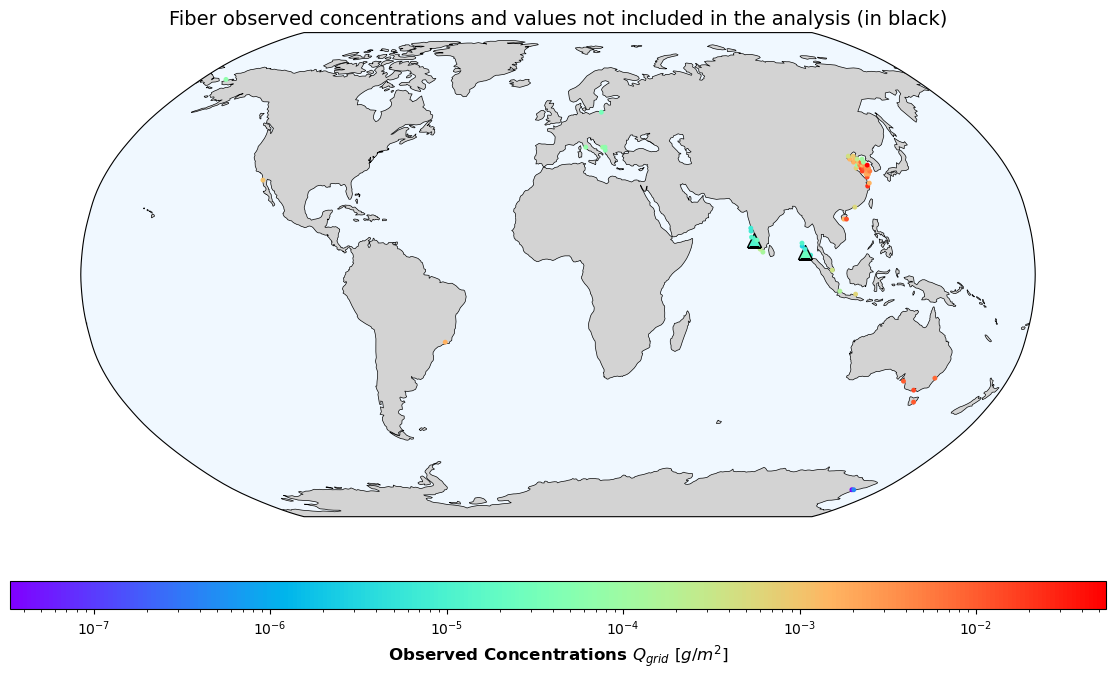

In [16]:
vmin = min(df_reduced['MEAN MP stock (g/m2) in 2021_fib'])
vmax = max(df_reduced['MEAN MP stock (g/m2) in 2021_fib'])
norm = LogNorm(vmin=vmin, vmax=vmax)

fig = plt.figure(figsize=(14, 7))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='aliceblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_global()

for row in range(len(df_reduced)):

    subset = df_reduced.iloc[row]

    if subset['index'] == 13 or subset['index'] == 19 :
        form = '^'
        size = 100
        edgecolor='black',
    else :
        form = '.'
        size = 50
        edgecolor = 'none'


    scatter = ax.scatter(subset['Lon_center'],subset['Lat_center'],
                    c=subset['MEAN MP stock (g/m2) in 2021_fib'], 
                    s=size,
                    marker = form,
                    cmap='rainbow',  # You can change this to 'plasma', 'hot', 'cool', etc.
                    norm=norm,  # Log scale for better visualization of wide range
                    zorder=5,
                    edgecolor=edgecolor,
                    transform=ccrs.PlateCarree())

    
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', 
                   pad=0.1, shrink=0.8, aspect=40)
cbar.set_label('Observed Concentrations $Q_{grid} \  [g/m^2]$', fontsize=12, fontweight='bold')

legend_elements = [
    Line2D([0], [0], marker='^', color='gray', linestyle='None', markersize=8, label='Fibers')
]

plt.title("Fiber observed concentrations and values not included in the analysis (in black)", fontsize=14)
plt.tight_layout()
plt.show()

### Spatial conditions

One of the acceptance conditions is that some identified data points can not be in the same cluster: Rio and Alaska, and Rio and Antarctica. These conditions have been selected based on observed MP fiber concentrations observed.

In [17]:
for row in range(len(df_all_world_expanded)):
    if -45 < df_all_world_expanded['Lon_center'].iloc[row] < -42 and -25 < df_all_world_expanded['Lat_center'].iloc[row] < -22 : 
        print('-----------------Rio-------------------------')
        print(df_all_world_expanded.iloc[row])

    if -167 > df_all_world_expanded['Lon_center'].iloc[row] > - 168 and 66 < df_all_world_expanded['Lat_center'].iloc[row] < 67 : 
        print('-----------------Alaska-------------------------')
        print(df_all_world_expanded.iloc[row])

    if -75 < df_all_world_expanded['Lat_center'].iloc[row] < -74 and  164 > df_all_world_expanded['Lon_center'].iloc[row] > 163 : 
        print('-----------------Antarctica-------------------------')
        print(df_all_world_expanded.iloc[row])

-----------------Antarctica-------------------------
Lat_center                           -7.450000e+01
Lon_center                            1.635000e+02
Depth                                -7.966667e+01
MP_std                                7.331212e+01
n_points                              6.000000e+00
uo_mean                                        NaN
Distance to land                      0.000000e+00
Distance Fishing nearest_point        4.296000e+01
Mean Precipitations over 1991-2021    6.916842e-01
MMPW/Area 100km                       0.000000e+00
Distance Meijer nearest_point         3.118552e+03
River Input 50km                      1.668110e+00
River Input 100km                     1.986781e+00
POC                                   2.848919e-01
PLAS_F                                2.422132e-11
O2                                    3.130356e+02
PO4                                   2.156806e+00
Sedimentation rate cm/yr              3.105920e-01
pwg_per_cap nearest_point / d

In [18]:
Antarctica = 149
Rio = 1466 
Alaska = 7202

## Functions of the model

In [19]:
def cluster_median_errors(df, cluster_col, conc_col, n_clust):
    """
    Computes MAE and MAPE between each point's true concentration
    and the median concentration of its assigned cluster.
    Returns MAE and MAPE averaged over all points.
    """
    # Build median lookup: cluster_id -> median concentration
    cluster_medians = {
        i: df.loc[df[cluster_col] == i, conc_col].median()
        for i in range(n_clust)
    }

    # Assign predicted value = median of point's cluster
    df_valid = df[[cluster_col, conc_col]].dropna()
    y_true = df_valid[conc_col].values
    y_pred = df_valid[cluster_col].map(cluster_medians).values

    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true) * 100)
    
    return mae, mape

In [29]:
def plot_3(colors, df, data_by_cluster, data_by_bin_frg, n_clust, mape, kept_in):

    """Creates a 3-panel figure with world map of clusters, fiber concentrations by cluster, and fragment concentrations by bins."""

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # --- Map ---
    ax_map = plt.subplot(131, projection=ccrs.Robinson())
    ax_map.add_feature(cfeature.LAND, facecolor='lightgray')
    ax_map.add_feature(cfeature.OCEAN, facecolor='aliceblue')
    ax_map.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax_map.set_global()

    for cluster_id in range(len(colors)):
        mask = df['Cluster'] == cluster_id
        ax_map.scatter(df.loc[mask, 'Lon_center'],
                       df.loc[mask, 'Lat_center'],
                       color=colors[cluster_id],
                       s=5, alpha=0.8,
                       transform=ccrs.PlateCarree(),
                       label=f'Cluster {cluster_id} (n={mask.sum()})',
                       zorder=5)
        
    #ax_map.legend(loc='lower left', fontsize=9)
    ax_map.legend(loc='upper left', bbox_to_anchor=(0.0,0.0))
    #ax_map.set_title('World Map')

    # --- Concentration plot ---
    ax_conc = plt.subplot(132)

    for cluster_id in range(len(colors)):
        mask = df['Cluster'] == cluster_id
        conc = df.loc[mask, 'MEAN MP stock (g/m2) in 2021_fib']
        ax_conc.scatter([cluster_id] * mask.sum(), conc,
                        color=colors[cluster_id], alpha=0.6, s=60,
                        label=f'Cluster {cluster_id}')
        

    ax_conc.boxplot(data_by_cluster, positions=np.arange(0,n_clust,1), widths=0.3,
                    patch_artist=True,
                    boxprops=dict(alpha=0.3),
                    medianprops=dict(color='black', linewidth=2))
    
    ax_conc.set_yscale('log')
    ax_conc.set_ylim(10E-10, 10E2)
    ax_conc.set_xticks(np.arange(0,n_clust,1))
    ax_conc.set_xticklabels(np.arange(0,n_clust,1))
    ax_conc.set_ylabel('Fiber MP Concentration (g/m²) in 2021', fontsize = 11,)
    ax_conc.set_title('Fiber concentration $\ Q_{cluster}$',fontsize = 15, fontweight='bold')
    ax_conc.legend()

    # --- Fragments plot ---
    ax_frg = plt.subplot(133)

    n_bins = len(data_by_bin_frg)

    colors_bin = ['tab:blue', 'tab:orange', 'pink']
    for bin_id, conc in enumerate(data_by_bin_frg):

        ax_frg.scatter(
            np.full(len(conc), bin_id),
            conc,
            alpha=0.6,
            s=60,
            label=f'Bin {bin_id}',
            color = colors_bin[bin_id]
        )

    ax_frg.boxplot(
        data_by_bin_frg,
        positions=np.arange(n_bins),
        widths=0.3,
        patch_artist=True,
        boxprops=dict(alpha=0.3),
        medianprops=dict(color='black', linewidth=2)
    )

    ax_frg.set_yscale('log')
    ax_frg.set_ylim(1e-9, 1e3)

    ax_frg.set_xticks(np.arange(n_bins))
    ax_frg.set_xticklabels(np.arange(n_bins))

    ax_frg.set_ylabel('Fragment MP Concentration (g/m²) in 2021', fontsize = 11,)
    ax_frg.set_title('Fragment concentration $ Q_{bin}$', fontsize = 15, fontweight='bold')

    ax_frg.legend()

    fig.suptitle(f'Features: {kept_in} | MAPE fib: {mape:.1f}%',
             fontsize=20,)

    plt.tight_layout()
    plt.show()

In [30]:
def log_bin_median_std(df, column, n_bins):

    """Distributes observed fragment concentrations into bins based on log-spaced statistics computed on the original concentrations."""

    x = df[column].dropna()

    if (x <= 0).any():
        raise ValueError("All values must be > 0 for log10 binning.")

    # Create log-spaced bins
    log_edges = np.linspace(
        np.log10(x.min()),
        np.log10(x.max()),
        n_bins + 1
    )

    edges = 10**log_edges

    temp = df.copy()

    temp["Bin"] = pd.cut(
        temp[column],
        bins=edges,
        labels=range(n_bins),
        include_lowest=True
    )

    summary = (
        temp.groupby("Bin", observed=True)[column]
        .agg(
            count="count",
            median="median",
            std="std",
            min="min",
            max="max",
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75)
        )
    )

    medians = summary["median"].tolist()
    q25s = summary["q25"].tolist()
    q75s = summary["q75"].tolist()

    data_by_bin = []

    for bin_id in range(n_bins):

        mask = temp["Bin"] == bin_id
        conc = temp.loc[mask, column]

        data_by_bin.append(conc.values)

    temp["Bin"] = pd.cut(temp[column], bins=edges, labels=range(n_bins), include_lowest=True)
    temp["Bin"] = temp["Bin"].astype("Int64")

    mae, mape = cluster_median_errors(temp.dropna(subset=["Bin"]), "Bin", column, n_clust=n_bins)

    return medians, q25s, q75s, data_by_bin, mape

In [31]:
def acceptance_conditions(n_clust, data_by_cluster,dataframe,
                          points_in_cluster,
                          mape_threshold,
                          median_value_constrain,
                          spatial_constrain):
    
    """Summarizes the  acceptence conditions. Outputs True if all conditions are met."""

    procede = False
    medians = []
    q25s = []
    q75s = []
    mape = 0

    # --------- Equal distribution ---------
    conc_points_in_cluster = []
    for i in range(n_clust):
        conc_points_in_cluster.append(data_by_cluster[i].count())

        if np.min(conc_points_in_cluster) >= points_in_cluster:
            procede = True
        else :
            #print('Echec : not enough concentration points in cluster')
            procede = False

    ## --------- MAPE treshold ---------
    if procede == True :
        if mape < mape_threshold:
            procede = True
        else :
            procede = False
            #print('Echec : MAPE treshold')

        

    ## --------- Median constraint ---------
    mae, mape = cluster_median_errors(dataframe, 'Cluster', 'MEAN MP stock (g/m2) in 2021_fib', n_clust) # Computes medians inside
    
    if procede == True and median_value_constrain != False:
            
        for i in range(n_clust):
            medians.append(data_by_cluster[i].median())
            q25s.append(data_by_cluster[i].quantile(0.25))
            q75s.append(data_by_cluster[i].quantile(0.75))

        min_distances = []
        for i in range(n_clust):
            min_distances.append(np.abs(np.delete(np.log10(medians[i]) - np.log10(np.array(medians)), [i])))

        if np.min(min_distances) >= median_value_constrain :
            procede = True
            
        else : 
            #print('Echec : Medians too close')
            procede = False


    if procede == True and median_value_constrain == False:
        print('No medain difference defined')
        procede = True
        

    ## --------- Spatial constraint ---------
    if pd.isna(dataframe['Cluster'].iloc[Rio]) or pd.isna(dataframe['Cluster'].iloc[Alaska]) or pd.isna(dataframe['Cluster'].iloc[Antarctica]):
        spatial = False
    else : 
        spatial = True

    if procede == True :
        if spatial == True :       
            if spatial_constrain == True:
                if dataframe['Cluster'].iloc[Rio] != dataframe['Cluster'].iloc[Alaska] and dataframe['Cluster'].iloc[Rio] != dataframe['Cluster'].iloc[Antarctica]: # Rio-Alaska & Rio-Antarctica
                    procede = True
                else :
                    #print('Echec : spatial distribution')
                    procede = False       

            else :
                print('spatial constraint not wanted')
                procede = True
        else :
            print('Spacial constraint not possible')

    return procede, medians, q25s, q75s, mape



In [32]:
def our_model(n_leave_out, n_clust, features_list, dataframe, mape_threshold, median_value_constrain, points_in_cluster, spatial_constrain, final):
    
    """The Model creates combinations of features based on leave-one-out algoritm.
       Each feature combination is considered as a individual input into a K-means clustering algorithm.
       The output of clustering is evaluated in the acceptance_conditions function.
       If all conditions are met, the output is visualized. 
       If demanded (final =True), the result is stored in a dataframe."""
    
    MAPE_score = [0,0]
    dataframe = dataframe.copy()
    
    ## Colors
    if n_clust == 2 : colors = {0: 'blue', 1: 'red'}
    elif n_clust == 3 : colors = {0: 'red', 1: 'green', 2: 'blue'} 
    elif n_clust == 4 : colors = {0: 'red', 1: 'green', 2: 'blue', 3: 'pink'} 
    else: print('REDEFINE COLORS! COLORS OUT OF RANGE')

    ## Features
    feature_subsets = [[f for f in features_list if f not in combo] for combo in combinations(features_list, n_leave_out)]
    print(f"{n_leave_out} features out means {len(feature_subsets)} total combinations")

    ## Leave out subsets
    for subset_idx, features in enumerate(feature_subsets):
        
        left_out = [f for f in features_list if f not in features]
        X_clust = dataframe[features].dropna()
        X_scaled = X_clust.values

        kmeans = KMeans(n_clusters=n_clust, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(X_scaled)

        dataframe['Cluster'] = None
        dataframe.loc[X_clust.index, 'Cluster'] = clusters
        dataframe['Cluster'] = dataframe['Cluster'].astype('Int64')
 

        data_by_cluster = []
        data_by_cluster_frg = []
        for i in range(len(colors)):
            data_by_cluster.append(dataframe.loc[dataframe['Cluster'] == i, 'MEAN MP stock (g/m2) in 2021_fib'].dropna())
            data_by_cluster_frg.append(dataframe.loc[dataframe['Cluster'] == i, 'MEAN MP stock (g/m2) in 2021_frg'].dropna())

        


        procede, medians, q25s, q75s, mape  = acceptance_conditions(n_clust, data_by_cluster, dataframe,
                          points_in_cluster,
                          mape_threshold,
                          median_value_constrain,
                          spatial_constrain)  
        
        ## Do not plot twice the same result
        if procede == True :
            MAPE_score.append(mape)

        if procede== True and MAPE_score[-1] != MAPE_score[-2] :
            medians_frg, q25s_frg, q75s_frg, data_by_bin_frg, mape_frg = log_bin_median_std(dataframe, 'MEAN MP stock (g/m2) in 2021_frg', n_clust)
            print(mape_frg)
                
            plot_3(colors, dataframe, data_by_cluster, data_by_bin_frg, n_clust, mape, features)
            


        ## Save the dataset with the correctly associated concentrations
        if final == True and procede == True:
            output_nona = dataframe.dropna(subset=['Cluster'])
            output_nona['Fibers Associated concentration (g/m2)'] = None
            output_nona['q25 fib'] = None
            output_nona['q75 fib'] = None
            output_nona['Fragments Associated concentration (g/m2)'] = None
            output_nona['q25 frg'] = None
            output_nona['q75 frg'] = None
            
            # Sort cluster indices by fiber median (ascending)
            sorted_clusters = sorted(range(n_clust), key=lambda i: medians[i])

            # Sort fragment bins by median (ascending)
            sorted_bins = sorted(range(n_clust), key=lambda i: medians_frg[i])

            # Map: cluster with rank k -> fragment bin with rank k
            cluster_to_bin = {sorted_clusters[k]: sorted_bins[k] for k in range(n_clust)}

            median_map     = {i: medians[i] for i in range(n_clust)}
            q25_map        = {i: q25s[i] for i in range(n_clust)}
            q75_map        = {i: q75s[i] for i in range(n_clust)}
            median_frg_map = {i: medians_frg[cluster_to_bin[i]] for i in range(n_clust)}
            q25_frg_map    = {i: q25s_frg[cluster_to_bin[i]] for i in range(n_clust)}
            q75_frg_map    = {i: q75s_frg[cluster_to_bin[i]] for i in range(n_clust)}


            output_nona['Fibers Associated concentration (g/m2)'] = output_nona['Cluster'].map(median_map)
            output_nona['q25 fib'] = output_nona['Cluster'].map(q25_map)
            output_nona['q75 fib'] = output_nona['Cluster'].map(q75_map)
            output_nona['Fragments Associated concentration (g/m2)'] = output_nona['Cluster'].map(median_frg_map)
            output_nona['q25 frg'] = output_nona['Cluster'].map(q25_frg_map)
            output_nona['q75 frg'] = output_nona['Cluster'].map(q75_frg_map)
                

            return output_nona

### Disponible features

In [33]:
world_features = ['Depth',
 'Distance to land',
 'Distance Fishing nearest_point',
 'Mean Precipitations over 1991-2021',
 'MMPW/Area 100km',
 'Distance Meijer nearest_point',
 'River Input 50km',
 'River Input 100km',
 'POC',
 'PLAS_F',
 'O2',
 'PO4',
 'Sedimentation rate cm/yr',
 'pwg_per_cap nearest_point / dist',
 'Population_2020 500km / dist']

world_features_reduced = ['Depth',
 'Distance to land',
 'Distance Fishing nearest_point',
 'Mean Precipitations over 1991-2021',
 'MMPW/Area 100km',
 'Distance Meijer nearest_point',
 'River Input 100km',
 'POC',
 'PLAS_F',
 'Sedimentation rate cm/yr',
 'pwg_per_cap nearest_point / dist',
 'Population_2020 500km / dist']

world_features_reduced_2 = ['Depth',
 'Distance Fishing nearest_point',
 'Mean Precipitations over 1991-2021',
 'MMPW/Area 100km',
 'Distance Meijer nearest_point',
 'POC',
 'PLAS_F',
 'Sedimentation rate cm/yr',
 'pwg_per_cap nearest_point / dist',
]

fiber_features = ['Distance Fishing nearest_point',
 'Mean Precipitations over 1991-2021',
 'MMPW/Area 100km',
 'POC',
 'PO4',
 'PLAS_F',
 'Sedimentation rate cm/yr',
 'River Input 100km',
 'pwg_per_cap nearest_point / dist']

fiber_features_that_work_for_two_clusters = [ 
        'MMPW/Area 100km', 'POC',
        'Sedimentation rate cm/yr', 
       'pwg_per_cap nearest_point / dist',]

fiber_features_that_work_for_three_clusters = [ 
        'MMPW/Area 100km', 'POC', 
       'pwg_per_cap nearest_point / dist',]



## Run

### Transform the features for better analysis

In [34]:
scaler = MinMaxScaler()
df_all_world_expanded_transformed = df_all_world_expanded.copy()
df_all_world_expanded_transformed[world_features] = scaler.fit_transform(df_all_world_expanded[world_features])

### Choose your features and acceptance conditions

In [35]:
features_that_work_for_two_clusters = ['MMPW/Area 100km', 'POC','Sedimentation rate cm/yr','pwg_per_cap nearest_point / dist',]
features_that_work_for_three_clusters = ['MMPW/Area 100km', 'POC','pwg_per_cap nearest_point / dist',]

In [36]:
n_clusters_list = [2] # list of clusters, value = 2 or 3
n_out_list = [0] # list of values
keep_results = True # keep the resulting dataset with associated concentrations for each cluster, True or False

features = features_that_work_for_two_clusters # Select the features to use for clustering
data = df_all_world_expanded # Select the dataframe to use for clustering

mape_error = 5000 # value or False, 1000 means one order of magnitude error allowed
median_value_constrain = 1 # value or False, 1 means that medians of clusters must be at least 1 order of magnitude apart
conc_points_in_cluster = 2 # number of points with associated concentration in a cluster, min value = 0
spatial_constrain = True # Rio - Alaska and Rio - Antarctica not together, True or False

### Run the model

0 features out means 1 total combinations
7720.144255074945


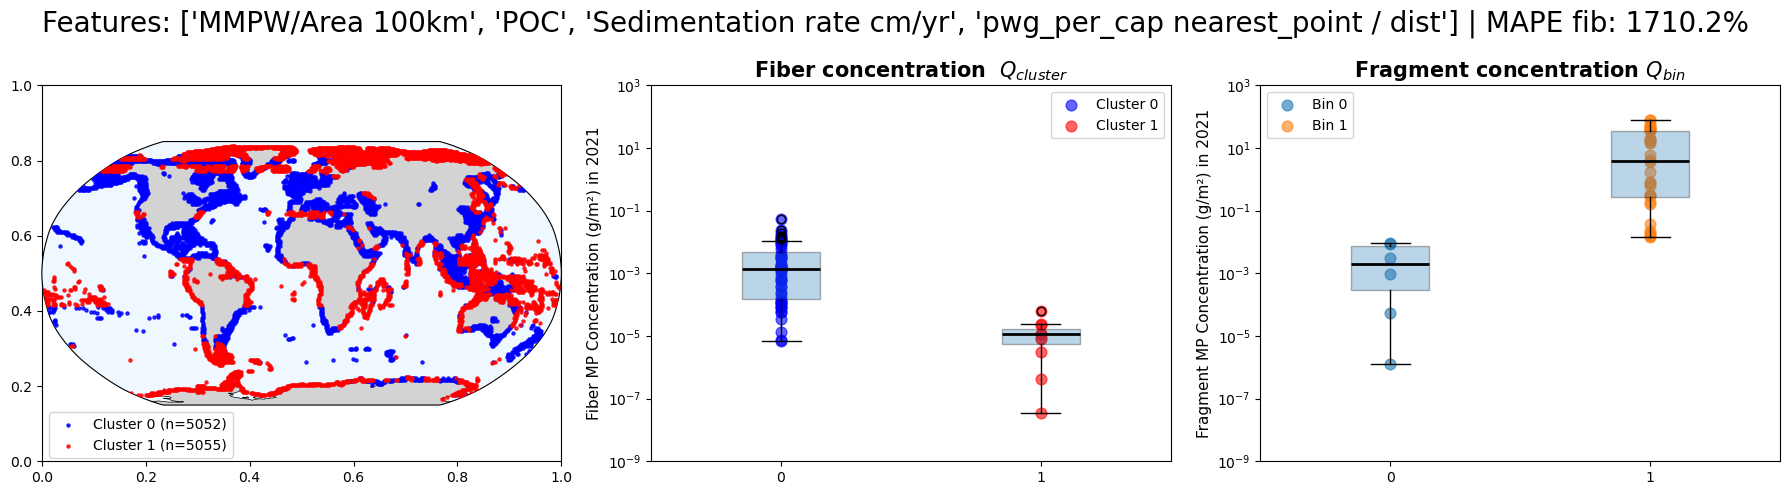

In [37]:
for n_clusters in n_clusters_list :
    for n_out in n_out_list :
        two_clusters = our_model(n_leave_out=n_out, n_clust = n_clusters,
                            features_list = features, dataframe = data,
                            mape_threshold = mape_error,
                            median_value_constrain=median_value_constrain,
                            points_in_cluster = conc_points_in_cluster,
                            spatial_constrain = spatial_constrain,
                            final = keep_results                                       
                     )

### Compare clusters with real concentrations on a plot

In [72]:
from matplotlib.colors import TwoSlopeNorm

In [38]:
def plot_clusters_with_observations(df, shapes):

    """Plots the clusters with associated concentrations and the observed concentrations on a world map."""

    df = df.copy()

    Lon_grid = df['Lon_center']
    Lat_grid = df['Lat_center']
    
    for shape in shapes:

        if shape == 'Fibers':
            column = 'MEAN MP stock (g/m2) in 2021_fib'
            marker_grid = 's'
            marker_obs = '^'
            conc_associated = df['Fibers Associated concentration (g/m2)']
            title = 'Fibers'


        elif shape == 'Fragments':
            column = 'MEAN MP stock (g/m2) in 2021_frg'
            marker_grid = 's'
            marker_obs = 'o'
            conc_associated = df['Fragments Associated concentration (g/m2)']
            title = 'Fragments'


        mask = df[column].notna()
        Lon_obs = df.loc[mask, 'Lon_center']
        Lat_obs = df.loc[mask, 'Lat_center']
        conc_obs = df.loc[mask, column]

        min_max_associated = [min(conc_associated), max(conc_associated)]
        min_max_obs = [min(conc_obs), max(conc_obs)]
  
        min_max = [min(min_max_associated[0], min_max_obs[0]), max(min_max_associated[1], min_max_obs[1])]
        norm = LogNorm(vmin=min(min_max), vmax=max(min_max))

        fig = plt.figure(figsize=(24, 14))
        ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
        ax.set_global()
        ax.add_feature(cfeature.LAND, facecolor="#e8e0d0")
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6)

        if shape == 'Fibers':
            marker_grid = 's'
            marker_obs = '^'
            color = 'seismic' # rainbow

        elif shape == 'Fragments':
            marker_grid = 's'
            marker_obs = 'D'
            color = 'seismic' #trubo

        mesh = ax.scatter(Lon_grid, Lat_grid,
                        c=conc_associated,
                        cmap=color,
                        norm=norm,
                        marker=marker_grid,
                        s=3,
                        zorder=4,
                        edgecolors='none',
                        linewidths=0,
                        transform=ccrs.PlateCarree())

        points = ax.scatter(Lon_obs, Lat_obs,
                        c=conc_obs,
                        cmap=color,
                        norm=norm,
                        marker=marker_obs,
                        s=80,
                        zorder=5,
                        edgecolors='black',
                        linewidths=1.1,
                        transform=ccrs.PlateCarree())

        cbar = plt.colorbar(points, ax=ax, orientation='horizontal', pad=0.1, shrink=0.8, aspect=40)
        cbar.set_label('MP Concentration (g/m2)', fontsize=20,)
        cbar.ax.tick_params(labelsize=16)

        plt.title(title, fontsize=24,fontweight='bold')

        plt.show()

We can visualize the two clusters in the background and supperpose them with the observed concentrations. Since the MP concentration is driven by fragments, idkwhat

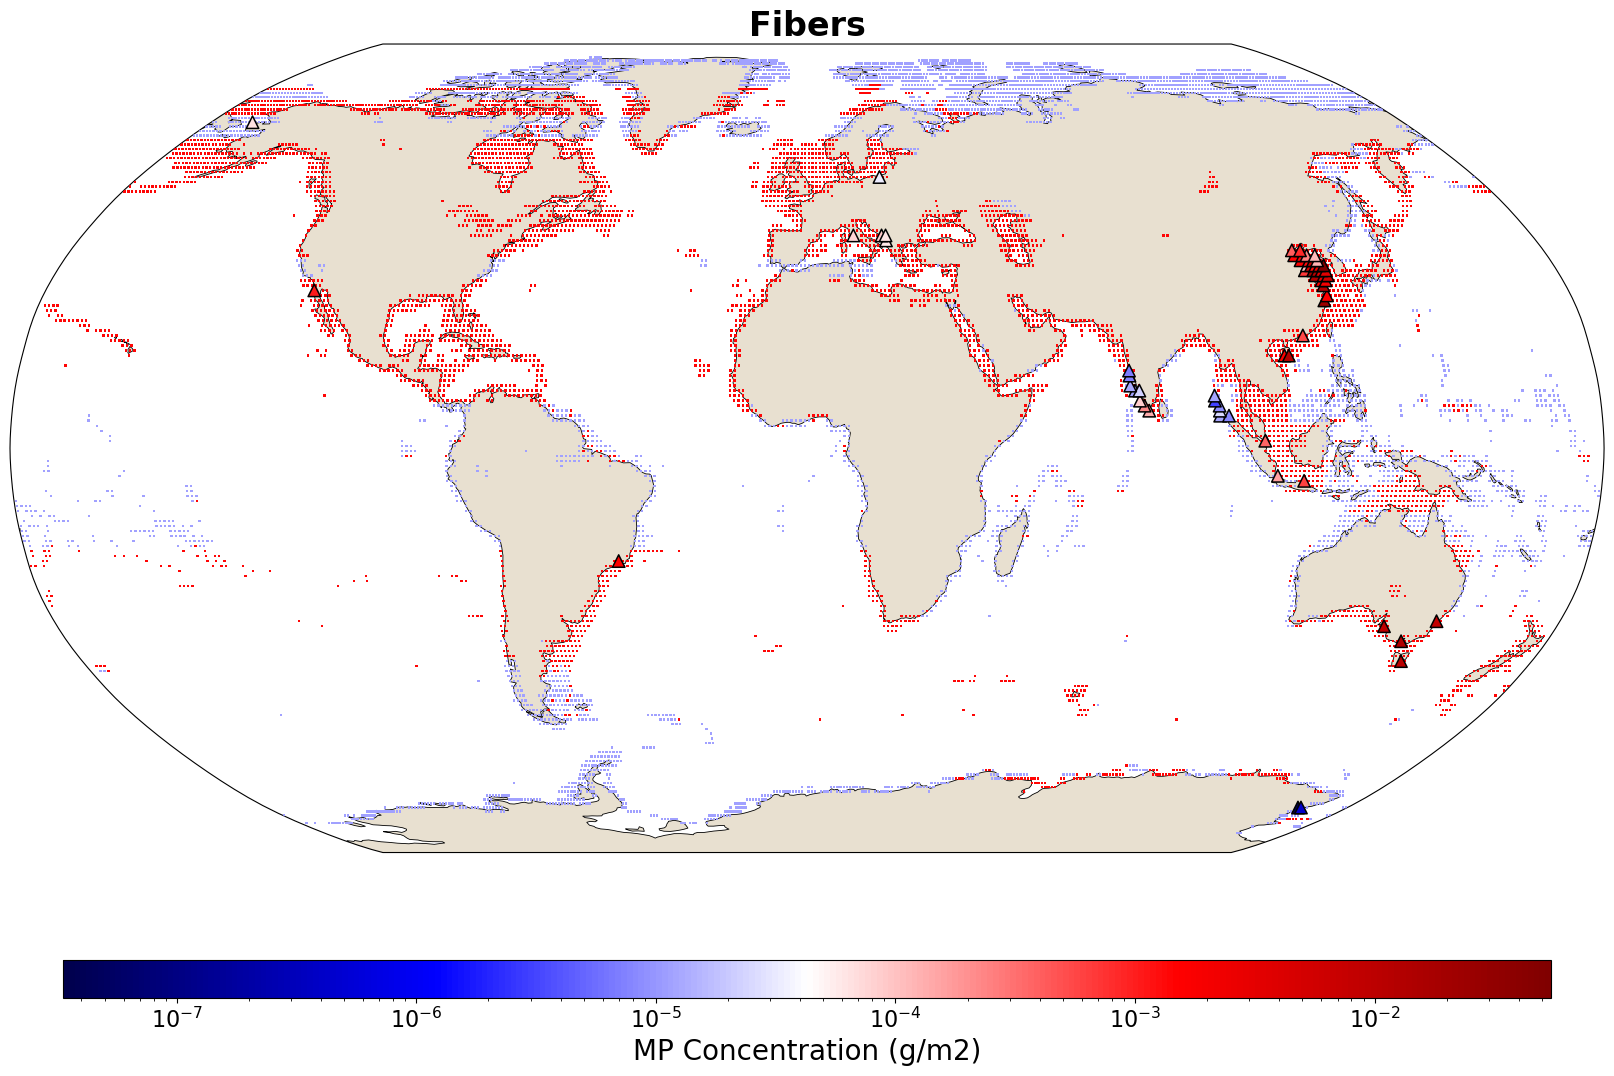

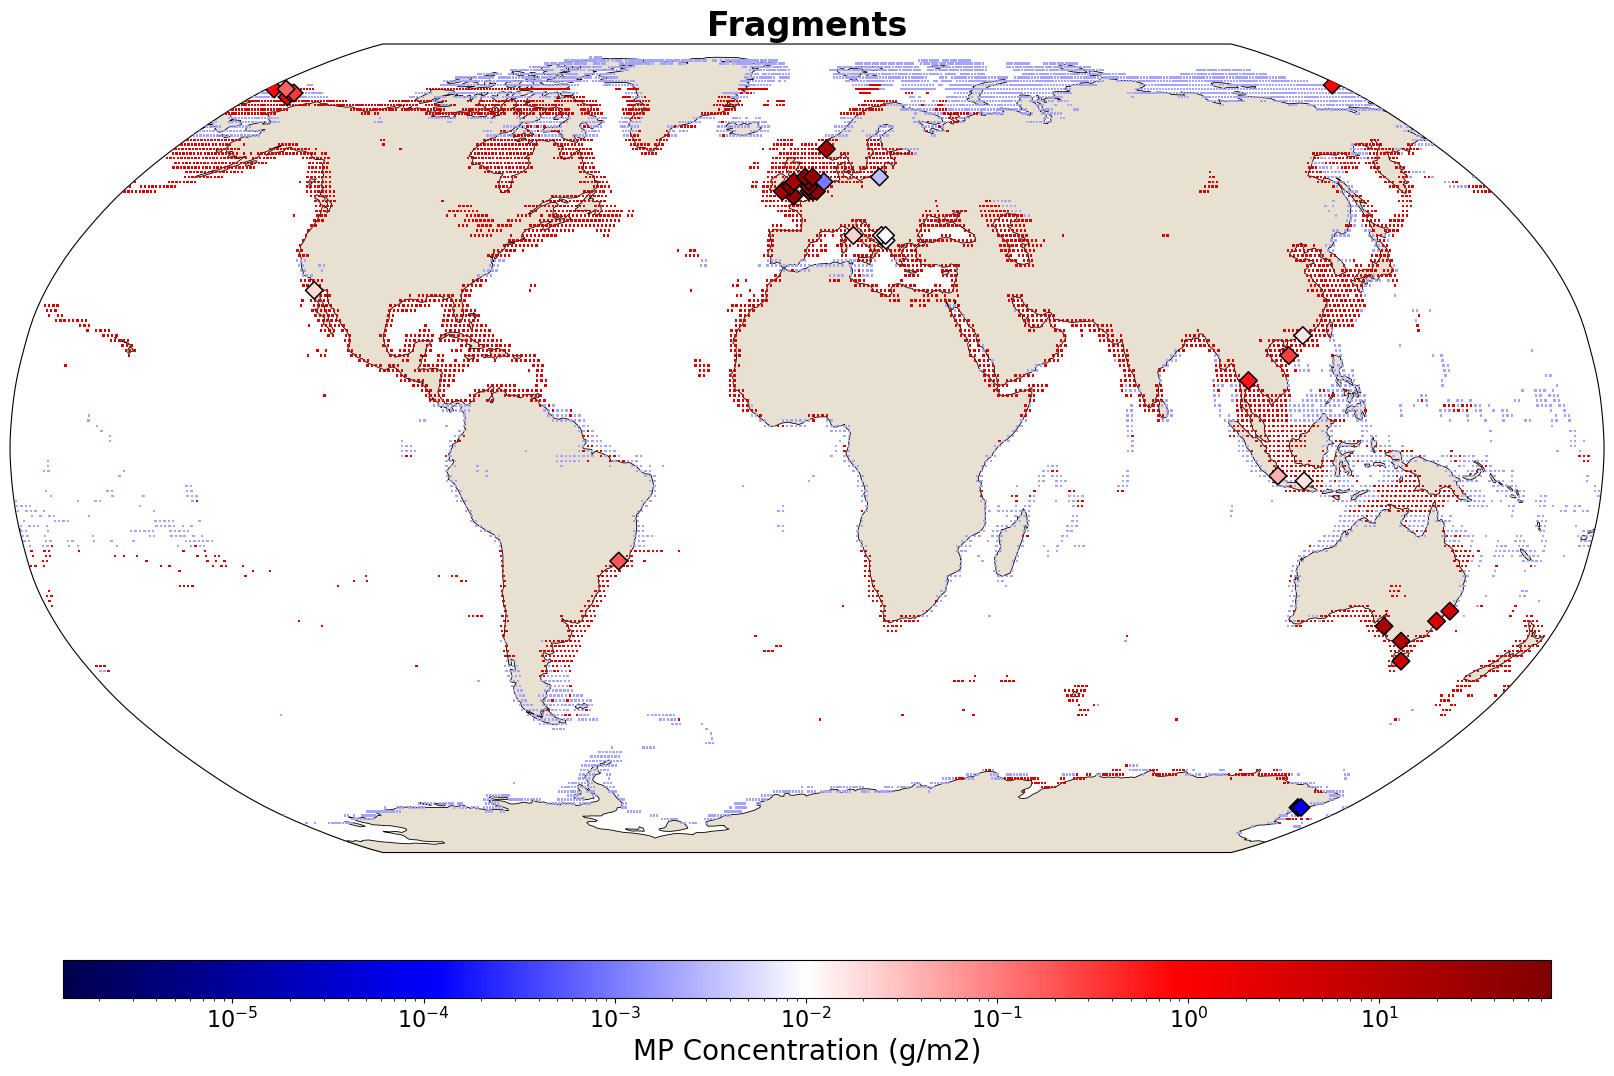

In [39]:
plot_clusters_with_observations(two_clusters, shapes = ['Fibers', 'Fragments'])

## Get total MP mass estimation $Q_{total} \ [Tg]$

### Functions

In [40]:
def cell_area_m2(lat_center, cell_size_deg=1.0):
    """
    Compute area of a grid cell in km² given its center latitude.
    Cell area varies with latitude due to Earth's curvature.
    """
    R = 6371  # Earth radius in km
    lat_rad = np.radians(lat_center)
    cell_rad = np.radians(cell_size_deg)
    
    area_km2 = (R**2) * (cell_rad) * (np.sin(lat_rad + cell_rad/2) - np.sin(lat_rad - cell_rad/2))  # in km2
    area_m2 = area_km2 * (1000**2)  # convert to m²
    return np.abs(area_m2)


In [41]:
two_clusters

,Lat_center,Lon_center,Depth,MP_std,n_points,uo_mean,Distance to land,Distance Fishing nearest_point,Mean Precipitations over 1991-2021,MMPW/Area 100km,...,index,MEAN MP stock (g/m2) in 2021_fib,MEAN MP stock (g/m2) in 2021_frg,Cluster,Fibers Associated concentration (g/m2),q25 fib,q75 fib,Fragments Associated concentration (g/m2),q25 frg,q75 frg
0,-81.5,160.5,-44.000000,16.522712,3,NaN,0.0,448.116864,0.401515,0.000000e+00,...,0,NaN,NaN,1,0.000011,0.000006,0.000017,0.002051,0.000286,0.007382
1,-81.5,161.5,-170.000000,4.242641,2,NaN,0.0,443.620441,0.401515,0.000000e+00,...,1,NaN,NaN,1,0.000011,0.000006,0.000017,0.002051,0.000286,0.007382
2,-79.5,160.5,-9.500000,2.121320,2,NaN,0.0,244.808513,0.389836,0.000000e+00,...,2,NaN,NaN,1,0.000011,0.000006,0.000017,0.002051,0.000286,0.007382
3,-79.5,175.5,-178.000000,NaN,1,NaN,31000.0,194.217273,0.482419,0.000000e+00,...,3,NaN,NaN,1,0.000011,0.000006,0.000017,0.002051,0.000286,0.007382
4,-79.5,176.5,-88.000000,121.622366,2,NaN,31000.0,190.495909,0.482419,0.000000e+00,...,4,NaN,NaN,1,0.000011,0.000006,0.000017,0.002051,0.000286,0.007382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10102,82.5,61.5,-195.666667,2.081666,3,-0.031601,0.0,281.150488,0.999476,1.541235e-04,...,10102,NaN,NaN,1,0.000011,0.000006,0.000017,0.002051,0.000286,0.007382
10103,83.5,-83.5,-198.000000,0.816497,4,-0.022676,20000.0,885.177163,0.551590,2.040479e-09,...,10103,NaN,NaN,1,0.000011,0.000006,0.000017,0.002051,0.000286,0.007382
10104,83.5,-81.5,-185.139241,8.988218,79,-0.024982,17000.0,896.664165,0.551590,2.040479e-09,...,10104,NaN,NaN,1,0.000011,0.000006,0.000017,0.002051,0.000286,0.007382
10105,83.5,-80.5,-158.419355,24.215193,124,-0.025097,19000.0,902.901515,0.551590,2.040479e-09,...,10105,NaN,NaN,1,0.000011,0.000006,0.000017,0.002051,0.000286,0.007382


In [42]:
def compute_total_mass(df):
    df_copy = df.copy()
    # Sum of fibers and fragments concentrations
    df_copy['Associated concentration (g/m2)'] =  (df_copy['Fibers Associated concentration (g/m2)'] + 
                                              df_copy['Fragments Associated concentration (g/m2)'])
    
    # Compute surface area of each cell
    df_copy['Cell_area_m2'] = df_copy['Lat_center'].apply(lambda lat: cell_area_m2(lat, cell_size_deg=1.0))

    # Multiply concentration by surface
    df_copy['Concentration (g) in grid cell'] = df_copy['Associated concentration (g/m2)'] * df_copy['Cell_area_m2']
    df_copy['Concentration (Tg) in grid cell'] = df_copy['Concentration (g) in grid cell'] * (10**-12)  # Convert g to Tg
    
    # Sum over all cells
    total_MP_in_sediments = df_copy['Concentration (Tg) in grid cell'].sum()

    print(f'MP concentrtion in world sediments : {total_MP_in_sediments} Tg')

    # Add error
    df_copy['Associated q25'] =  (df_copy['q25 fib'] + df_copy['q25 frg'])
    df_copy['Associated q75'] =  (df_copy['q75 fib'] + df_copy['q75 frg'])

    df_copy['q25 (g) in grid cell'] = df_copy['Associated q25'] * df_copy['Cell_area_m2']
    df_copy['q75 (g) in grid cell'] = df_copy['Associated q75'] * df_copy['Cell_area_m2']

    df_copy['q25 (Tg) in grid cell'] = df_copy['q25 (g) in grid cell'] * (10**-12)  # Convert g to Tg
    df_copy['q75 (Tg) in grid cell'] = df_copy['q75 (g) in grid cell'] * (10**-12)  # Convert g to Tg


    tatal_q25 = df_copy['q25 (Tg) in grid cell'].sum()
    tatal_q75 = df_copy['q75 (Tg) in grid cell'].sum()

    print(f'MP concentrtion in world sediments : {total_MP_in_sediments} Tg with IQR :({tatal_q75} - {tatal_q25})')

    return total_MP_in_sediments, df_copy

### First estimate

In [43]:
Q_total,two_clusters_result = compute_total_mass(two_clusters)

MP concentrtion in world sediments : 171.70125239785676 Tg
MP concentrtion in world sediments : 171.70125239785676 Tg with IQR :(1591.8365539395659 - 12.010652995516935)


In [44]:
two_clusters_result['Cell_area_m2'].sum()

np.float64(77118045177894.31)

### PCA analysis

Explained variance: PC1=61.73%, PC2=38.27%
Total: 99.99%
                                       PC1       PC2
MMPW/Area 100km                   0.001422 -0.000454
POC                               0.910518 -0.413464
Sedimentation rate cm/yr          0.413464  0.910520
pwg_per_cap nearest_point / dist -0.001800  0.000389


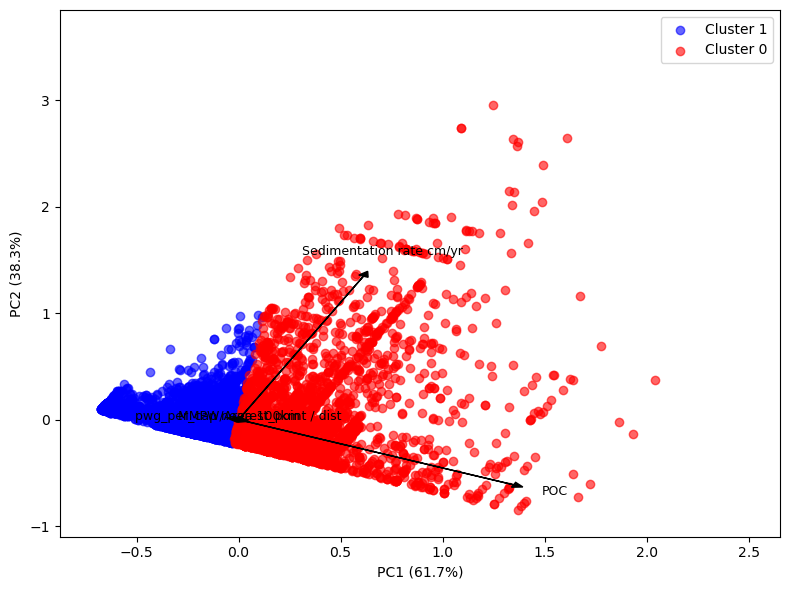

In [45]:

features_4 = ['MMPW/Area 100km', 'POC', 'Sedimentation rate cm/yr', 'pwg_per_cap nearest_point / dist']  


X = two_clusters[features_4].dropna()
clusters = two_clusters.loc[X.index, 'Cluster']

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")
print(f"Total: {sum(pca.explained_variance_ratio_):.2%}")

# Loadings - which features drive each PC
loadings = pd.DataFrame(pca.components_.T, index=features_4, columns=['PC1', 'PC2'])
print(loadings)

scale = np.max(np.abs(X_pca)) * 0.5  # scale to half the data range
colors = ['red','blue','green']
fig, ax = plt.subplots(figsize=(8, 6))
for cluster_id in two_clusters['Cluster'].dropna().unique():
    mask = clusters == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {cluster_id}', alpha=0.6,c=colors[cluster_id])

for i, feature in enumerate(features_4):
    x = pca.components_[0, i] * scale
    y = pca.components_[1, i] * scale
    ax.arrow(0, 0, x, y, head_width=0.05, head_length=0.05,
             fc='black', ec='black', zorder=5)
    ax.text(x * 1.15, y * 1.15, feature, fontsize=9, ha='center')

ax.set_xlim(X_pca[:, 0].min() * 1.3, X_pca[:, 0].max() * 1.3)
ax.set_ylim(X_pca[:, 1].min() * 1.3, X_pca[:, 1].max() * 1.3)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend()
plt.tight_layout()
plt.show()

### Transform the features back

In [113]:
# Inverse transform on full dataframe
df_all_world_expanded[world_features] = scaler.inverse_transform(df_all_world_expanded_transformed[world_features])

# Merge on Lat_center and Lon_center
two_clusters_bt = two_clusters_result.drop(columns=world_features)  # remove scaled columns
two_clusters_bt = two_clusters_bt.merge(df_all_world_expanded[['Lat_center', 'Lon_center'] + world_features],
                                   on=['Lat_center', 'Lon_center'],
                                   how='left')

### Manually correct the coastal shelf areas

In [137]:
df = two_clusters_bt.copy()

baikal    = (df['Lon_center'].between(67.0, 116.0)) & (df['Lat_center'].between(38.0, 60.0))
amazone   = (df['Lon_center'].between(-79.0, -52.0)) & (df['Lat_center'].between(-7.0, 2.0))
australia = (df['Lon_center'].between(134.0, 147.0)) & (df['Lat_center'].between(-31.0, -21.0))
kanada = (df['Lon_center'].between(-95.0, -74.0)) & (df['Lat_center'].between(40.0, 49.0))
kanada2 = (df['Lon_center'].between(-127.0, -115.0)) & (df['Lat_center'].between(59.0, 67.0))

df = df[~(baikal | amazone | australia | kanada | kanada2)].reset_index(drop=True)

two_clusters_no_lakes = df

In [138]:
def adjust_total_mass(df):
    df_copy = df.copy()
    # Sum of fibers and fragments concentrations
    df_copy['Associated concentration (g/m2)'] =  (df_copy['Fibers Associated concentration (g/m2)'] + 
                                              df_copy['Fragments Associated concentration (g/m2)'])
    
    # Compute surface area of each cell
    df_copy['Cell_area_m2'] = df_copy['Lat_center'].apply(lambda lat: cell_area_m2(lat, cell_size_deg=1.0))


    # Water part
    df_copy['Cell_water_area_m2'] = df_copy['Cell_area_m2'] * (df_copy['n_points']/np.max(df_copy['n_points']))

    # Multiply concentration by surface
    df_copy['Concentration (g) in grid cell'] = df_copy['Associated concentration (g/m2)'] * df_copy['Cell_water_area_m2']
    df_copy['Concentration (Tg) in grid cell'] = df_copy['Concentration (g) in grid cell'] * (10**-12)  # Convert g to Tg
    
    # Sum over all cells
    total_MP_in_sediments = df_copy['Concentration (Tg) in grid cell'].sum()

    print(f'MP concentrtion in world sediments : {total_MP_in_sediments} Tg')

    # Add error
    df_copy['Associated q25'] =  (df_copy['q25 fib'] + df_copy['q25 frg'])
    df_copy['Associated q75'] =  (df_copy['q75 fib'] + df_copy['q75 frg'])

    df_copy['q25 (g) in grid cell'] = df_copy['Associated q25'] * df_copy['Cell_water_area_m2']
    df_copy['q75 (g) in grid cell'] = df_copy['Associated q75'] * df_copy['Cell_water_area_m2']

    df_copy['q25 (Tg) in grid cell'] = df_copy['q25 (g) in grid cell'] * (10**-12)  # Convert g to Tg
    df_copy['q75 (Tg) in grid cell'] = df_copy['q75 (g) in grid cell'] * (10**-12)  # Convert g to Tg


    tatal_q25 = df_copy['q25 (Tg) in grid cell'].sum()
    tatal_q75 = df_copy['q75 (Tg) in grid cell'].sum()

    print(f'MP concentrtion in world sediments : {total_MP_in_sediments} Tg with IQR :({tatal_q75} - {tatal_q25})')

    return total_MP_in_sediments, df_copy

In [139]:
new_total_MP_in_sediments, two_clusters_adjusted =  adjust_total_mass(two_clusters_no_lakes)

MP concentrtion in world sediments : 67.68597820796069 Tg
MP concentrtion in world sediments : 67.68597820796069 Tg with IQR :(627.5617078335038 - 4.734100294677418)


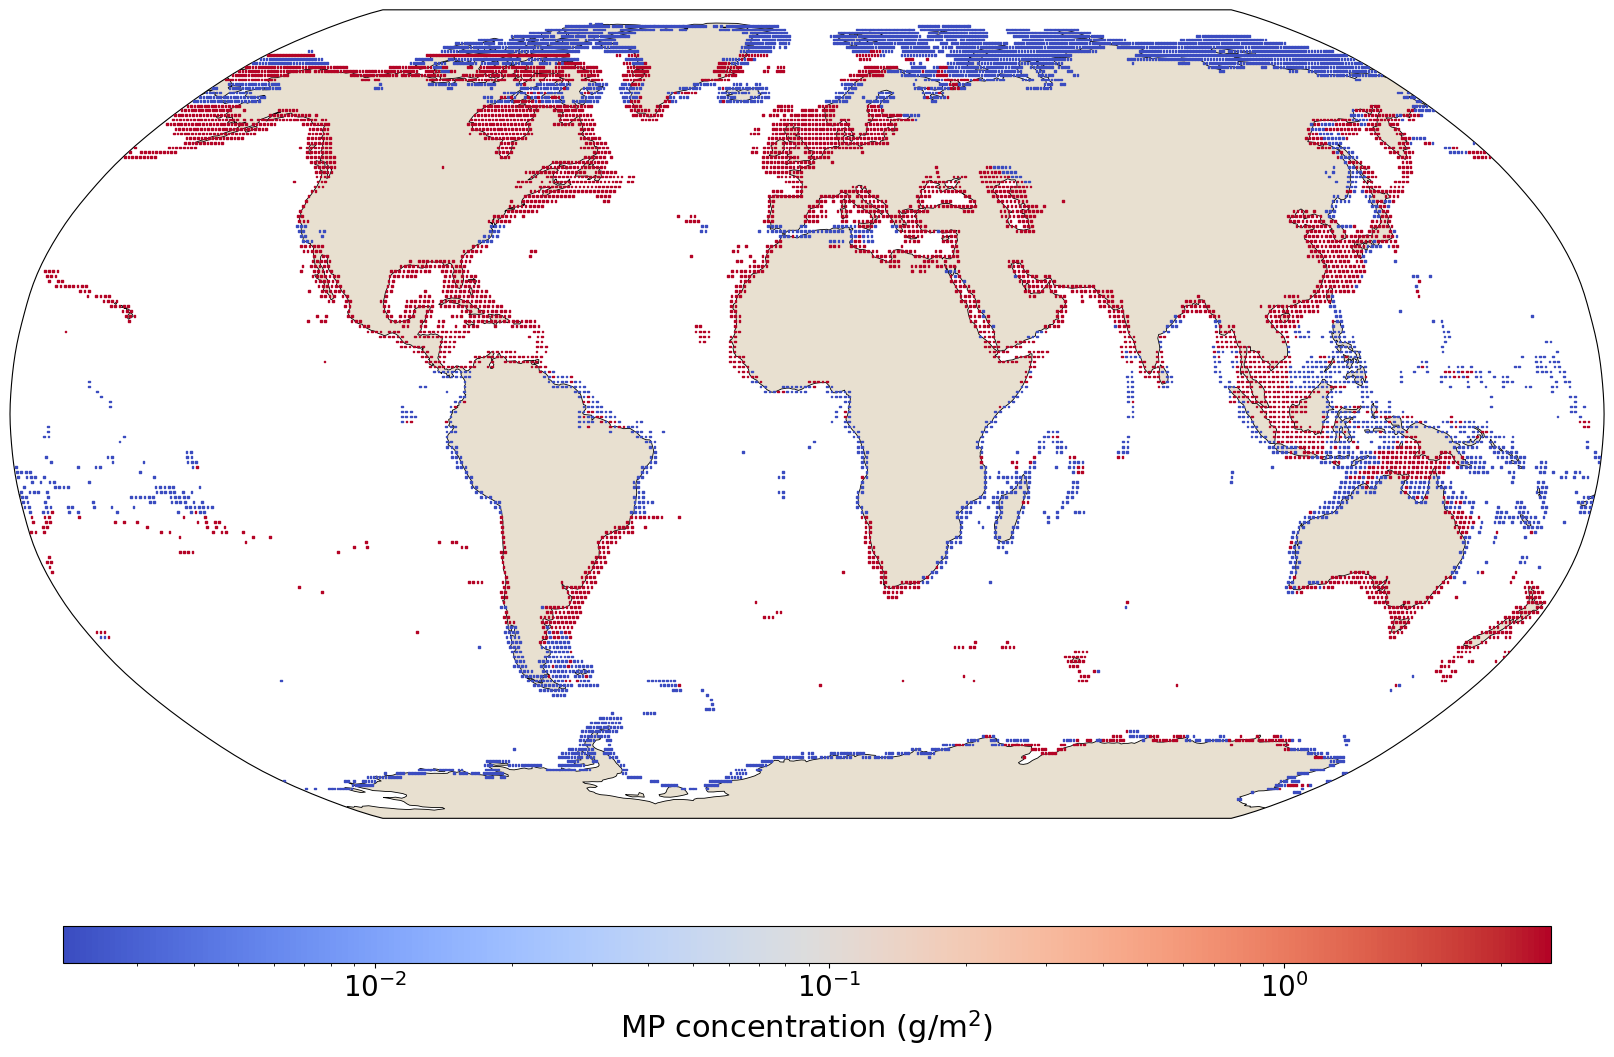

In [140]:
mask = two_clusters_adjusted['n_points'] >= 20
mask2 = two_clusters_adjusted['Depth'] <= -2
#base_reduced = two_clusters_bt[mask]
#base_reduced = base_reduced[mask2]
base_reduced = two_clusters_adjusted

Lon_grid = base_reduced['Lon_center']
Lat_grid = base_reduced['Lat_center']
concentration = base_reduced['Associated concentration (g/m2)']
#concentration = base_reduced['Depth']

min_max = [min(concentration), max(concentration)]

norm = LogNorm(vmin=min_max[0], vmax=min_max[1])

fig = plt.figure(figsize=(24, 14))

ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor="#e8e0d0")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
#ax.set_extent([115, 135, 29, 42], crs=ccrs.PlateCarree())


mesh = ax.scatter(Lon_grid, Lat_grid,
                  c=concentration,
                  cmap='coolwarm',
                  norm = norm,
                  #vmin = min(concentration),
                  #vmax = max(concentration),
                  marker='s',  # square marker
                  s=1.5,       # ADUJST HERE TO MAKE A GOOD SQUARES
                  zorder=4,
                  transform=ccrs.PlateCarree())


cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.1, shrink=0.8, aspect=40)
cbar.set_label('MP concentration (g/m$^2$)', fontsize=22,)
cbar.ax.tick_params(labelsize=20)
#plt.title(f'Corrected total MP mass in world sediments : {base_reduced["Concentration (Tg) in grid cell"].sum():.0f} Tg', fontsize=14)
plt.show()

In [141]:
base_reduced['Cell_water_area_m2'].sum()

np.float64(26371568032011.945)

In [136]:
77118045177894

77118045177894